In [1]:
# import sys
# !{sys.executable} -m pip install selenium webdriver-manager

In [2]:
import selenium
print("Selenium working now!")

Selenium working now!


In [3]:
from selenium import webdriver

### Web scrapping of a youtube page.

In [5]:
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time

In [6]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)
driver.get("https://www.youtube.com/c/GeeksforGeeksVideos/videos")

In [7]:
soup = BeautifulSoup(driver.page_source, "html.parser")

In [8]:
soup

<html dark="" darker-dark-theme="" darker-dark-theme-deprecate="" lang="en" style="font-size: 10px;font-family: Roboto, Arial, sans-serif;" system-icons="" typography="" typography-spacing=""><head><script id="js-1124342058" nonce="" src="https://static.doubleclick.net/instream/ad_status.js"></script><script data-original-src="/s/player/50cc0679/player_es6.vflset/en_US/miniplayer.js" nonce="" src="/s/player/50cc0679/player_es6.vflset/en_US/miniplayer.js"></script><script data-original-src="/s/player/50cc0679/player_es6.vflset/en_US/remote.js" nonce="" src="/s/player/50cc0679/player_es6.vflset/en_US/remote.js"></script><script data-original-src="/s/player/50cc0679/player_es6.vflset/en_US/offline.js" nonce="" src="/s/player/50cc0679/player_es6.vflset/en_US/offline.js"></script><script data-id="_gd" nonce="">window.WIZ_global_data = {"AfY8Hf":true,"HiPsbb":0,"MUE6Ne":"youtube_web","MuJWjd":false,"UUFaWc":"%.@.null,1000,2]","cfb2h":"youtube.web-front-end-critical_20251221.10_p0","fPDxwd":[

In [9]:
soup.text.replace('\n',"")

"GeeksforGeeks - YouTube      Back      INSkip navigation        Search        Search with your voiceSign in  INHome      Home  Shorts      Shorts  Subscriptions      Subscriptions  You      You  History      History  GeeksforGeeks@GeeksforGeeksVideos•1.16M subscribers•3.9K videosWelcome to the Official Channel of GeekforGeeks, your one-stop destination for diverse tech education! ...moreWelcome to the Official Channel of GeekforGeeks, your one-stop destination for diverse tech education! ...more...moregeeksforgeeks.org/coursesand 5 more linksSubscribeHomeVideosShortsLiveCoursesPlaylistsPosts  \xa0Search   PreviousLatestPopularOldest  Next2:42:47    2:42:47  Now playing2:42:472:42:47    2:42:47  Now playingDSA In Java | Hashmap 01 | Java in One Shot | Hashmap in Java••715 views16 hours ago6:13    6:13  Now playing6:136:13    6:13  Now playingSynthetic Empathy Explained | Are Machines Replacing Human Connection?••565 views2 days ago6:29    6:29  Now playing6:296:29    6:29  Now playingT

In [10]:
sp = soup.find_all('ytd-rich-item-renderer')

In [11]:
len(sp)

30

In [12]:
print(sp[0])

<ytd-rich-item-renderer class="style-scope ytd-rich-grid-renderer" is-in-first-column="" is-slim-grid="" items-per-row="3" lockup="true" no-gutter-margins="" rendered-from-rich-grid=""><!--css-build:shady--><!--css_build_scope:ytd-rich-item-renderer--><!--css_build_styles:video.youtube.src.web.polymer.shared.ui.styles.yt_base_styles.yt.base.styles.css.js--><div class="style-scope ytd-rich-item-renderer" id="content"><ytd-rich-grid-media class="style-scope ytd-rich-item-renderer" lockup="true" mini-mode=""><!--css-build:shady--><!--css_build_scope:ytd-rich-grid-media--><!--css_build_styles:video.youtube.src.web.polymer.shared.ui.styles.yt_base_styles.yt.base.styles.css.js--><div class="style-scope ytd-rich-grid-media" id="dismissible"><div class="style-scope ytd-rich-grid-media" id="thumbnail"><ytd-thumbnail class="style-scope ytd-rich-grid-media" loaded="" rich-grid-thumbnail="" size="large" use-hovered-property="" width="9999"><!--css-build:shady--><!--css_build_scope:ytd-thumbnail-->

In [13]:
sp[0].text   # 1st vedio on the youtube page 

'\n\n2:42:47\n    2:42:47\n  Now playing\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n2:42:47\n2:42:47\n    2:42:47\n  Now playing\n\n\n\n\n\n\n\n\n\n\n\nDSA In Java | Hashmap 01 | Java in One Shot | Hashmap in Java\n\n\n\n\n\n\n\n\n\n\n\n\n\n•\n\n\n\n\n•\n715 views\n16 hours ago\n\n\n\n\n\n\n\n\n'

In [14]:
# Scrap Title of the vedio
sp[0].find('a', class_="yt-simple-endpoint focus-on-expand style-scope ytd-rich-grid-media").text

'DSA In Java | Hashmap 01 | Java in One Shot | Hashmap in Java'

In [15]:
# Scrap link of the vedio
sp[0].find('a', class_="yt-simple-endpoint focus-on-expand style-scope ytd-rich-grid-media").get('href')

'/watch?v=0DJifcw2UGI'

In [16]:
sp[0].find_all('span')

[<span aria-label="2 hours, 42 minutes, 47 seconds" class="style-scope ytd-thumbnail-overlay-time-status-renderer" id="text">
     2:42:47
   </span>,
 <span class="style-scope ytd-thumbnail-overlay-now-playing-renderer" id="overlay-text">Now playing</span>,
 <span aria-label="2 hours, 42 minutes, 47 seconds" class="style-scope ytd-thumbnail-overlay-time-status-renderer" id="text">
     2:42:47
   </span>,
 <span class="style-scope ytd-thumbnail-overlay-now-playing-renderer" id="overlay-text">Now playing</span>,
 <span class="yt-icon-shape ytSpecIconShapeHost"><div style="width: 24px; height: 24px; display: block; fill: currentcolor;"><svg aria-hidden="true" focusable="false" height="24" style="pointer-events: none; display: inherit; width: 100%; height: 100%;" viewbox="0 0 24 24" width="24" xmlns="http://www.w3.org/2000/svg"><path d="M12 1C5.925 1 1 5.925 1 12s4.925 11 11 11 11-4.925 11-11S18.075 1 12 1Zm5.707 7.293a1 1 0 010 1.414L10 17.414l-3.707-3.707a1 1 0 111.414-1.414L10 14.586l

In [17]:
sp[0].find_all('span', class_='inline-metadata-item style-scope ytd-video-meta-block')

[<span class="inline-metadata-item style-scope ytd-video-meta-block">715 views</span>,
 <span class="inline-metadata-item style-scope ytd-video-meta-block">16 hours ago</span>]

In [18]:
# views
sp[0].find_all('span', class_='inline-metadata-item style-scope ytd-video-meta-block')[0].text

'715 views'

In [19]:
# time
sp[0].find_all('span', class_='inline-metadata-item style-scope ytd-video-meta-block')[1].text

'16 hours ago'

### Data from channel page

In [21]:
data = []

for sp in soup.find_all('ytd-rich-item-renderer'):
    # title 
    title = sp.find('a', class_="yt-simple-endpoint focus-on-expand style-scope ytd-rich-grid-media").text
    # video_link = sp.find('a', class_="yt-simple-endpoint focus-on-expand style-scope ytd-rich-grid-media").get('href')

    a_tag = sp.find('a', class_="yt-simple-endpoint focus-on-expand style-scope ytd-rich-grid-media")
    raw_link = a_tag.get('href')
    video_link = "https://www.youtube.com" + raw_link
    
    # views
    try:
        views = sp.find_all('span', class_='inline-metadata-item style-scope ytd-video-meta-block')[0].text
    except:
        views = None

    # time
    try:
        date_time = time = sp.find_all('span', class_='inline-metadata-item style-scope ytd-video-meta-block')[1].text
    except:
        date_time = None
        

    data.append([title, video_link, views, date_time])

# driver.quit()

In [22]:
data

[['DSA In Java | Hashmap 01 | Java in One Shot | Hashmap in Java',
  'https://www.youtube.com/watch?v=0DJifcw2UGI',
  '715 views',
  '16 hours ago'],
 ['Synthetic Empathy Explained | Are Machines Replacing Human Connection?',
  'https://www.youtube.com/watch?v=gCMGXwUiUDw',
  '565 views',
  '2 days ago'],
 ['Top AI Tools in 2025 | Complete AI Tier List Explained',
  'https://www.youtube.com/watch?v=w70XVzGO6vQ',
  '902 views',
  '5 days ago'],
 ['DSA In Java | Heap 02 | Java in One Shot | Heap in Java',
  'https://www.youtube.com/watch?v=IZz-Q4L5c4A',
  '2K views',
  '6 days ago'],
 ['Free AIMT by GfG | All India Mock Test Details & Registration Process',
  'https://www.youtube.com/watch?v=1ne4JugUKv8',
  '958 views',
  '7 days ago'],
 ['MERN vs Data Science | Salary, Jobs & Future Scope Explained',
  'https://www.youtube.com/watch?v=tCbgJZbblLU',
  '3.3K views',
  '8 days ago'],
 ['All About GATE 2027 | Syllabus | Exam Pattern | Cut Off | Eligibility Criteria | GATE 2027 Roadmap',
  '

In [23]:
import pandas as pd
df = pd.DataFrame(data, columns = ['title','video_link','views','date_time'])

In [24]:
df

,title,video_link,views,date_time
0,DSA In Java | Hashmap 01 | Java in One Shot | ...,https://www.youtube.com/watch?v=0DJifcw2UGI,715 views,16 hours ago
1,Synthetic Empathy Explained | Are Machines Rep...,https://www.youtube.com/watch?v=gCMGXwUiUDw,565 views,2 days ago
2,Top AI Tools in 2025 | Complete AI Tier List E...,https://www.youtube.com/watch?v=w70XVzGO6vQ,902 views,5 days ago
3,DSA In Java | Heap 02 | Java in One Shot | Hea...,https://www.youtube.com/watch?v=IZz-Q4L5c4A,2K views,6 days ago
4,Free AIMT by GfG | All India Mock Test Details...,https://www.youtube.com/watch?v=1ne4JugUKv8,958 views,7 days ago
5,"MERN vs Data Science | Salary, Jobs & Future S...",https://www.youtube.com/watch?v=tCbgJZbblLU,3.3K views,8 days ago
6,All About GATE 2027 | Syllabus | Exam Pattern ...,https://www.youtube.com/watch?v=m_CY-DIv6Pk,3.4K views,9 days ago
7,Free Courses FAQs | Nation SkillUp | Utilize N...,https://www.youtube.com/watch?v=PNjj29gbIo0,5.2K views,11 days ago
8,Ultimate Gen AI Project for Students | Build a...,https://www.youtube.com/watch?v=96Xr3KTU7S4,760 views,11 days ago
9,When Should You Use Generative AI? (Real-World...,https://www.youtube.com/watch?v=QN60QTMKWBk,501 views,12 days ago


In [25]:
df.isnull().sum()

title         0
video_link    0
views         0
date_time     0
dtype: int64

In [51]:
df.to_csv('data.csv', index = False)

### keyword frequency from scraped YouTube video titles using WordCloud.

In [57]:
titles = [row[0] for row in data]
text = " ".join(titles)

In [59]:
text

'DSA In Java | Hashmap 01 | Java in One Shot | Hashmap in Java Synthetic Empathy Explained | Are Machines Replacing Human Connection? Top AI Tools in 2025 | Complete AI Tier List Explained DSA In Java | Heap 02 | Java in One Shot | Heap in Java Free AIMT by GfG | All India Mock Test Details & Registration Process MERN vs Data Science | Salary, Jobs & Future Scope Explained All About GATE 2027 | Syllabus | Exam Pattern | Cut Off | Eligibility Criteria | GATE 2027 Roadmap Free Courses FAQs | Nation SkillUp | Utilize Nation Skillup to Learn & Win Rewards! Ultimate Gen AI Project for Students | Build a Real-World AI When Should You Use Generative AI? (Real-World Examples) What Is Technical Scripter? Content Writing Event by GeeksforGeeks DSA In Java | Heap 01 | Java in One Shot | Heap in Java Winter Training  with IBM Certification + New Kolkata GfG Centre Announcement Get a Job as a Data Analyst Before 2026 Starts | Complete Roadmap How to Prepare for Google SDE? Complete Roadmap & Strate

In [61]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove symbols
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

cleaned_text = clean_text(text)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhawn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [80]:
cleaned_text

'dsa java hashmap java one shot hashmap java synthetic empathy explained machines replacing human connection top ai tools complete ai tier list explained dsa java heap java one shot heap java free aimt gfg india mock test details registration process mern vs data science salary jobs future scope explained gate syllabus exam pattern cut eligibility criteria gate roadmap free courses faqs nation skillup utilize nation skillup learn win rewards ultimate gen ai project students build realworld ai use generative ai realworld examples technical scripter content writing event geeksforgeeks dsa java heap java one shot heap java winter training ibm certification new kolkata gfg centre announcement get job data analyst starts complete roadmap prepare google sde complete roadmap strategy big update free courses ending soon gfg national skill ai change future coding mustwatch dsa java binary search tree java one shot binary search tree java react hacked understanding reactshell vulnerability expla

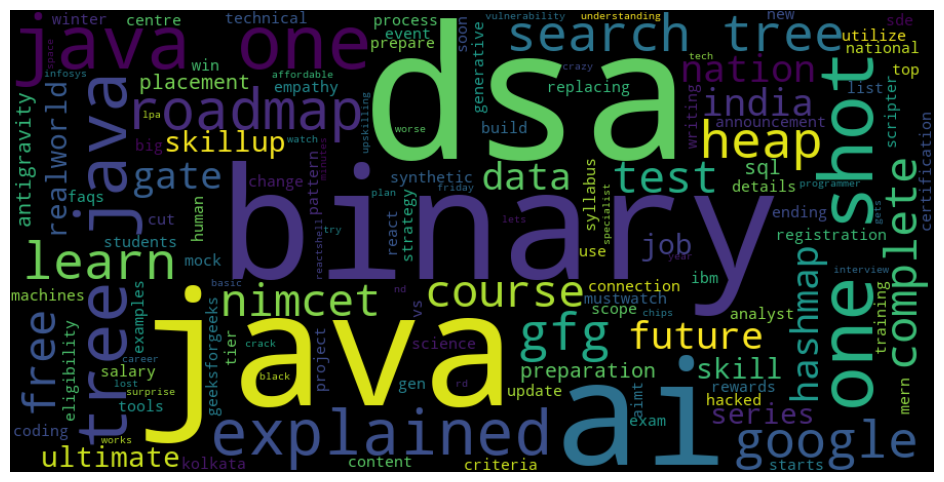

In [77]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='black',
)

wordcloud.generate(cleaned_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
